# **An Evaluation of Algorithmic Bias and Fragility in Rate My Professor Sentiment Analysis Model**

**Course project:** Stress test a TF-IDF sentiment classifier, deliberately overfit it, break it with adversarial inputs, and audit it for systematic bias.

**Structure**

1.   Introduction
2. Goals
3. Setup & Data Loading
4. Dataset Pre-processing
5. Training, Testing, & Baseline Model
6. Overfitting
7. Failures
8. Bias Analysis
9. References



##1. **Introduction**

This loads the **real dataset** that was used for the projects baseline.

Rate-my-professor (RMP) is a well-known website among university students used to read reviews of both schools and professors. It could be a deciding factor when it comes to course selection, as students might want to avoid classes with unpopular professors or heavy workloads. Because these are subjective opinions, we can use sentiment analysis as a neutral tool to classify them into positive or negative categories (Gong et al., 2022). However, the model can become fragile under small wording changes, overfit to surface-level patterns, and reproduce harmful social biases present in the training data (Diaz et al., 2018; Liu et al., 2023). Because RMP’s reviews usually contain informal language, slang, sarcasm, emotion, and comments about identity, they provide an excellent setting to study how classical machine learning models perform with high levels of noise and emotionally heavy text (Savini & Caragea, 2020).



## 2. **Goals**

The goal is to test and gather information about the performance of each baseline given the highly emotional characteristic of the dataset. Also, it is important to show that strong accuracy of the models can potentially hide important weaknesses and biases that will eventually make false predictions (Zheng et al., 2023). After training and evaluation, the project will stress-test the models through overfitting experiments, adversarial examples, and bias test cases. Finally, an audit report will be written to show how these models succeed, where they fail, and why those failures matter in context.

The project is designed for beginning students in the machine learning and analytics field where a model needs to be built from scratch with a pre-labeled dataset. Basic mathematical algorithms will be used to train and test the data, and how traditional NLP pipelines convert language into numeric features and how linear classifiers operate in high dimensional space. . Also, it helps learners understand that strong standard accuracy metrics can hide a lot of vulnerabilities like algorithmic fragility and harmful biases (Diaz et al., 2018).


## 3. **Setup & Data Loading**

Loads the real dataset that our projects baseline used.

In [4]:
from __future__ import annotations
import re
import random
import pickle
import numpy as np
import pandas as pd
import statistics as st
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import Dict, Optional, List, Tuple
from plotnine import *
from wordcloud import WordCloud, STOPWORDS
from joblib import dump
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, f1_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [5]:
# source dataset from real Rate My Professor reviews via Github
DATA_URL = "https://media.githubusercontent.com/media/vxuv/ratemyprofessor-dataset/refs/heads/main/reviews.csv"

# downloads the url and sorts by date (returns the FULL sorted dataframe, not yet limited to top 10,000)
def load_and_sort_data(url: str) -> pd.DataFrame:
    df = pd.read_csv(url)

    # converts to actual datetime objects
    df["date_cleaned"] = df["date"].str.replace(r"(\d+)(st|nd|rd|th)", r"\1", regex=True)
    df["date_cleaned"] = pd.to_datetime(df["date_cleaned"], format="%b %d, %Y")
    return df.sort_values(by="date_cleaned", ascending=False)

# df_sorted is now a top-level variable, so later cells (like the one that builds
# final_df_cleaned) can reuse the full sorted corpus instead of just the top 10,000
df_sorted = load_and_sort_data(DATA_URL)

# quick top 10,000 preview
target_columns = ["emotional_label", "comment", "quality", "would_take_again", "difficulty", "grade", "attendence"]
final_df = df_sorted.head(10000)[target_columns].copy()
final_df = final_df.rename(columns={"attendence": "attendance"})
display(final_df.head())

,emotional_label,comment,quality,would_take_again,difficulty,grade,attendance
3238869,awesome,"In my own opinion, I say that the teacher is a...",5.0,True,5.0,A-,Mandatory
3203743,awful,<TEACHER> is a great lecturer. I had a hard ti...,2.0,NaN,2.0,A-,Not Mandatory
3204422,average,Test reviews are nothing like the actual test....,3.0,NaN,3.0,Incomplete,Mandatory
3261158,awesome,Decent.,5.0,True,5.0,B+,Mandatory
3261157,awesome,Decent,5.0,True,5.0,B,Mandatory


##4. **Dataset Pre-Processing**

Cleans the raw review test by removing placeholder comments, strips extra whitespace, and drops rows with missing comments. The datasets raw sentiment labels into three classes awful, neutral, and great. The model has a clear target to learn from after cleaning.

In [6]:
# we filter out the invalid comments "Not specified", "None", "na", "n/a", "no comment"
placeholders = ["Not Specified", "Not Specified.", "None", "None.", "none", "N/A", "no", "NA", "n/a", ".", "na", "na.", "No Comment", "...", "Decent", "Decent."]
pattern = "|".join([f"^{p}$" for p in placeholders])

# added "quality" back to the target columns list
target_columns = ["emotional_label", "tags", "comment", "would_take_again", "difficulty", "quality", "grade", "attendance"]

# pre-filter the sorted dataframe
temp_df = df_sorted.copy().rename(columns={"attendence": "attendance"})
temp_df = temp_df[temp_df["comment"].notna()]
temp_df = temp_df[~temp_df["comment"].str.strip().str.contains(pattern, case=False, na=False)]

# remove comments below 20 character and take the most recent 10000 from the remaining cleaned set
temp_df = temp_df[temp_df["comment"].str.len() >= 20]
final_df_cleaned = temp_df.head(10000)[target_columns].copy()

print(f"Total valid reviews found: {len(temp_df)}")
print(f"Rows in final cleaned dataset: {len(final_df_cleaned)}")
display(final_df_cleaned.head())

Total valid reviews found: 3213112
Rows in final cleaned dataset: 10000


,emotional_label,tags,comment,would_take_again,difficulty,quality,grade,attendance
3238869,awesome,['EXTRA CREDIT'],"In my own opinion, I say that the teacher is a...",True,5.0,5.0,A-,Mandatory
3203743,awful,['Get ready to read'],<TEACHER> is a great lecturer. I had a hard ti...,NaN,2.0,2.0,A-,Not Mandatory
3204422,average,['Get ready to read'],Test reviews are nothing like the actual test....,NaN,3.0,3.0,Incomplete,Mandatory
3262621,awesome,['Clear grading criteria'],"Her class is so easy, she only has two large p...",True,5.0,5.0,A+,Mandatory
3253177,awesome,['Clear grading criteria'],Classtime was super chill and there wasn't a l...,True,4.0,4.0,Rather not say,Mandatory


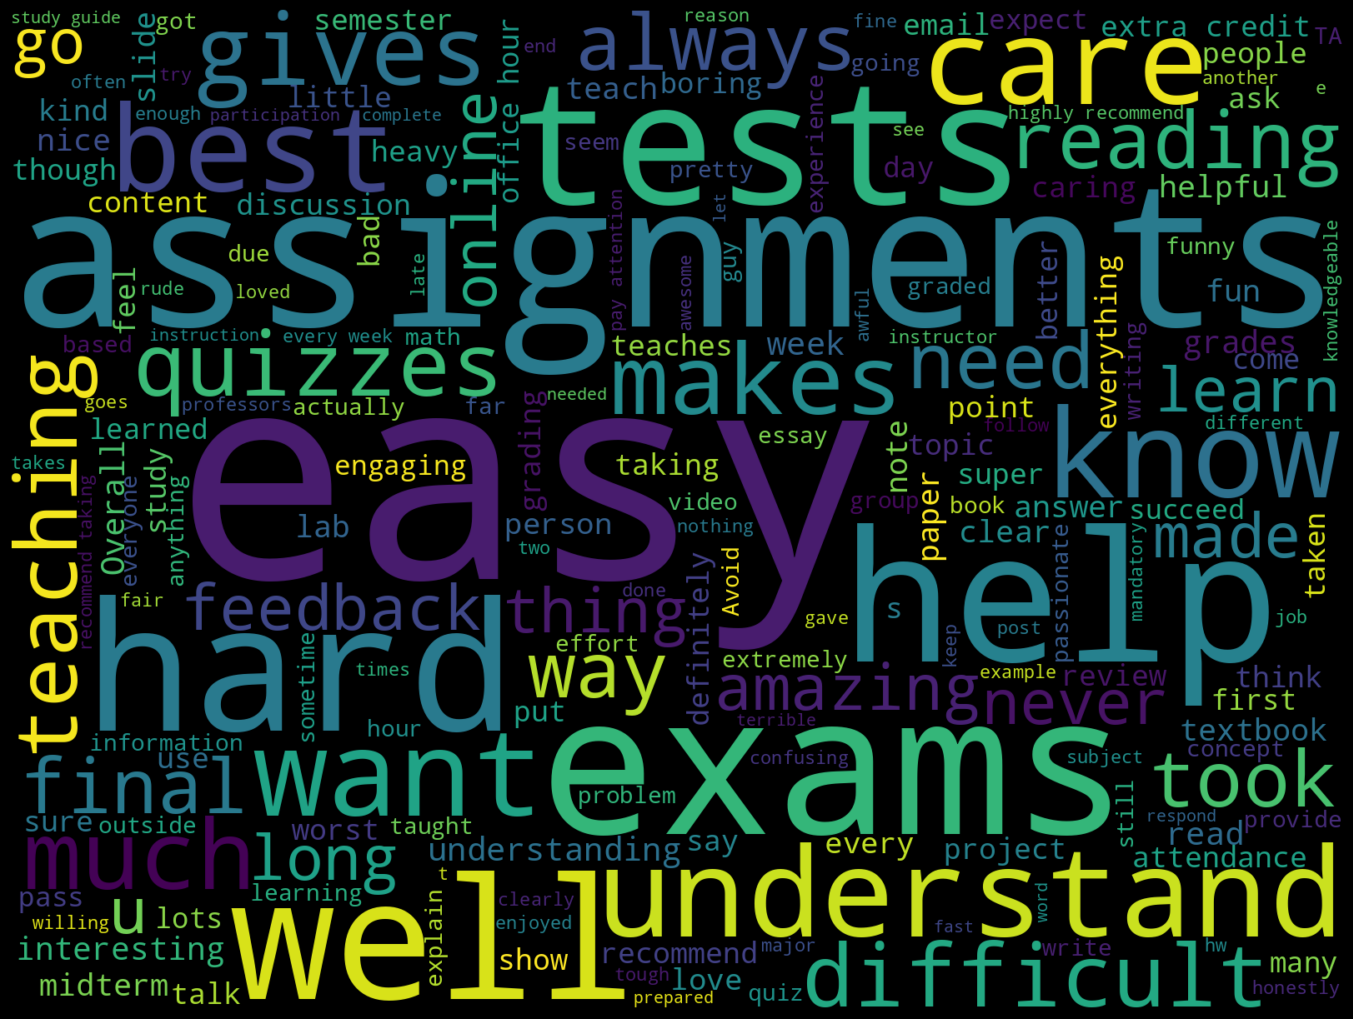

In [7]:
# birds-eye view of vocabulary, not a systematic check for anything specific
stopwords = set(STOPWORDS)
user_stopwords = [
    "lecture", "lectures", "class", "classes", "lot", "tell", "student", "students",
    "take", "will", "make", "give", "course", "teacher", "professor", "prof",
    "test", "exam", "assignment", "homework", "grade", "one", "really", "even",
    "good", "great", "time", "work", "material", "question", "questions", "TEACHER"
]
stopwords.update([word.lower() for word in user_stopwords])

sentences = " ".join(final_df_cleaned["comment"].astype(str))
wordcloud = WordCloud(width=1600, height=1200, background_color="black", stopwords=stopwords).generate(sentences)

# creates the figure
plt.figure(figsize=(20,10), facecolor="k")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [8]:
from queue import PriorityQueue
@dataclass
class Config:
    text_col: str = "comment"
    label_col: str = "emotional_label"
    random_state: int = RANDOM_STATE
    test_size: float = 0.2

# translates messy/inconsistent raw label strings to "Awful", "Neutral", or "Great"
LABEL_MAP_DEFAULT: Dict[str, str] = {
    "awful": "Awful",
    "bad": "Awful",
    "terrible": "Awful",
    "average": "Neutral",
    "neutral": "Neutral",
    "ok": "Neutral",
    "awesome": "Great",
    "great": "Great",
    "good": "Great",
    "excellent": "Great",
}

# small text cleaning function for inconsistencies
def normalize_whitespace(text: str) -> str:
    text = str(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

# uses a row's raw label to convert it to one of the three label strings
def map_label(raw_label: str, label_map: Dict[str, str]) -> Optional[str]:
    if raw_label is None or (isinstance(raw_label, float) and pd.isna(raw_label)):
        return None
    key = str(raw_label).strip().lower()
    return label_map.get(key)

# ties together normalize_whitespace and map_label to help create a training dataset
def prepare_data(df: pd.DataFrame, cfg: Config, label_map: Dict[str, str]) -> pd.DataFrame:
    df = df.copy()
    df[cfg.text_col] = df[cfg.text_col].astype(str).map(normalize_whitespace)
    df["label"] = df[cfg.label_col].map(lambda x: map_label(x, label_map))

    # drop rows we can't train on
    df = df.dropna(subset=[cfg.text_col, "label"]).copy()

    # remove empty strings after cleaning
    df = df[df[cfg.text_col].str.len() > 0].copy()
    return df

# constructes the actual machine learning model
def build_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    sublinear_tf=True,
                    norm="l2",
                ),
            ),
            (
                "clf",
                LinearSVC(class_weight="balanced", random_state=42),
            ),
        ]
    )

# main execution logic using the existing final_df_cleaned
cfg = Config()
processed_df = prepare_data(final_df_cleaned, cfg, LABEL_MAP_DEFAULT)

print(f"Loaded {len(processed_df)} labeled rows.")
print(processed_df["label"].value_counts())


Loaded 10000 labeled rows.
label
Great      5523
Awful      3826
Neutral     651
Name: count, dtype: int64


## 5. **Training & Testing**

Splits the cleaned data into training and test sets. Then trains the two versions one with a grid search and the other kepy simple. Both regularized and used for comparison later.

In [9]:
X_vals = processed_df[cfg.text_col].values
y_vals = processed_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_vals,
    y_vals,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    stratify=y_vals,
)

pipe = build_pipeline()

# hyperparameter search
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [10000, 20000],
    "clf__C": [0.5, 1.0, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.random_state)
search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("\nBest params:", search.best_params_)

y_pred = best_model.predict(X_test)
print("\nHoldout accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# save model
dump(best_model, "tfidf_rmp_model.joblib")
print("\nSaved trained pipeline to: tfidf_rmp_model.joblib")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'clf__C': 0.5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}

Holdout accuracy: 0.85

Classification report:
               precision    recall  f1-score   support

       Awful     0.8542    0.8654    0.8597       765
       Great     0.9033    0.9050    0.9042      1105
     Neutral     0.3220    0.2923    0.3065       130

    accuracy                         0.8500      2000
   macro avg     0.6932    0.6875    0.6901      2000
weighted avg     0.8468    0.8500    0.8483      2000


Saved trained pipeline to: tfidf_rmp_model.joblib


In [10]:
# baseline model, defensible and regularized
def build_lr_pipeline(ngram_range=(1, 1), min_df=2, max_df=0.9, max_features=None, C=1.0) -> Pipeline:
    return Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            lowercase=True, strip_accents="unicode", sublinear_tf=True, norm="l2",
            ngram_range=ngram_range, min_df=min_df, max_df=max_df, max_features=max_features,
        )),
        ("clf", LogisticRegression(
            max_iter=4000, solver="saga", class_weight="balanced", C=C,
        )),
    ])

# this reference point we will later deliberately break
baseline_model = build_lr_pipeline(ngram_range=(1, 1), min_df=2, max_df=0.9, C=1.0)
baseline_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train))
test_acc = accuracy_score(y_test, baseline_model.predict(X_test))
print(f"Baseline train accuracy: {train_acc:.4f}")
print(f"Baseline test accuracy:  {test_acc:.4f}")
print()
print(classification_report(y_test, baseline_model.predict(X_test), digits=4))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge


Baseline train accuracy: 0.7994
Baseline test accuracy:  0.7525

              precision    recall  f1-score   support

       Awful     0.8375    0.7882    0.8121       765
       Great     0.9495    0.7484    0.8370      1105
     Neutral     0.1834    0.5769    0.2783       130

    accuracy                         0.7525      2000
   macro avg     0.6568    0.7045    0.6425      2000
weighted avg     0.8569    0.7525    0.7912      2000



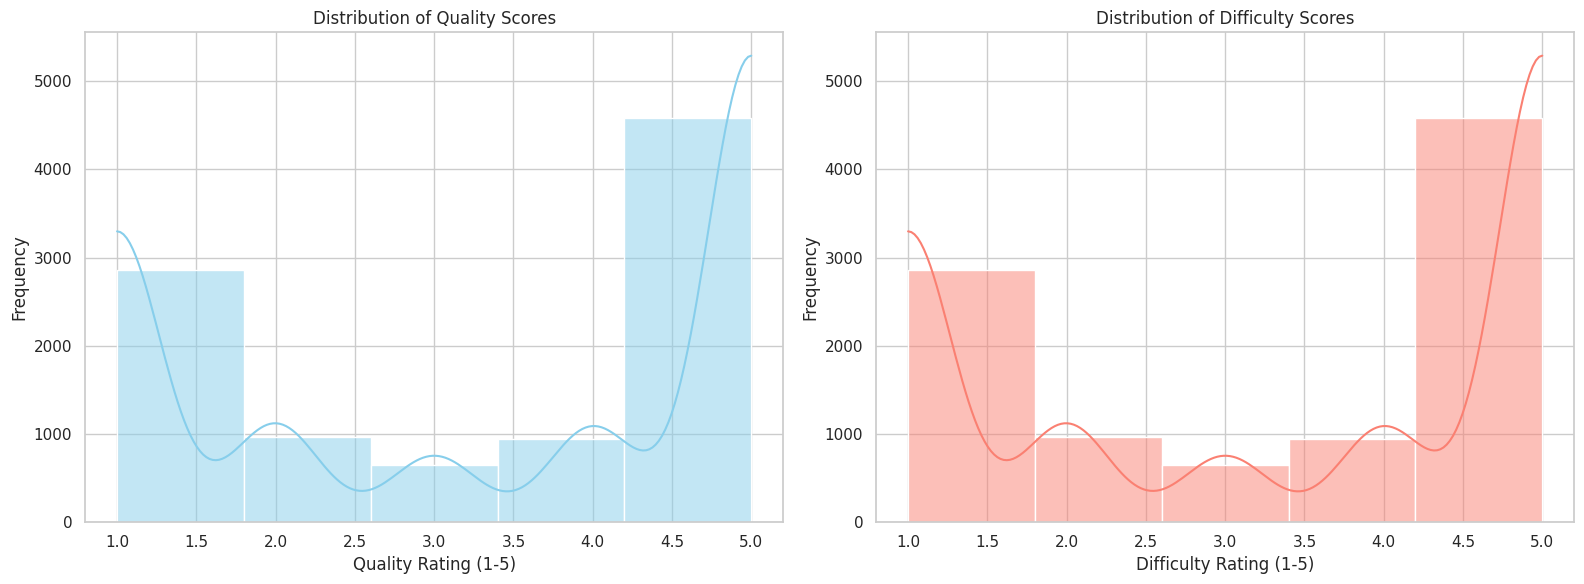

In [11]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# quality Score Distribution
sns.histplot(final_df_cleaned["quality"], bins=5, kde=True, color="skyblue", ax=ax1)
ax1.set_title("Distribution of Quality Scores")
ax1.set_xlabel("Quality Rating (1-5)")
ax1.set_ylabel("Frequency")

# difficulty Score Distribution
sns.histplot(final_df_cleaned["difficulty"], bins=5, kde=True, color="salmon", ax=ax2)
ax2.set_title("Distribution of Difficulty Scores")
ax2.set_xlabel("Difficulty Rating (1-5)")
ax2.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

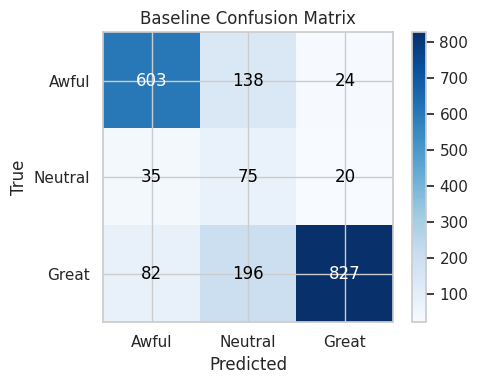

In [12]:
# visualization number one based on 10,000 recent reviews
labels_order = ["Awful", "Neutral", "Great"]
cm = confusion_matrix(y_test, baseline_model.predict(X_test), labels=labels_order)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order)
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Baseline Confusion Matrix")
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 6. **Overfitting**

Trains the model based on five levels of complexity and compares training accuracy. The training accuracy rises towards perfect as the complexity levels increase. The growing gap is the overfitting being made visible.

In [13]:
# drives the overfitting demonstration for the model
complexity_grid = [
    {"label": "Low (unigram, min_df=5, C=0.1)",    "ngram_range": (1, 1), "min_df": 5, "C": 0.1},
    {"label": "Baseline (unigram, min_df=2, C=1.0)","ngram_range": (1, 1), "min_df": 2, "C": 1.0},
    {"label": "Medium (bigram, min_df=1, C=10)",     "ngram_range": (1, 2), "min_df": 1, "C": 10.0},
    {"label": "High (trigram, min_df=1, C=100)",      "ngram_range": (1, 3), "min_df": 1, "C": 100.0},
    {"label": "Very high (4-gram, min_df=1, C=1000)", "ngram_range": (1, 4), "min_df": 1, "C": 1000.0},
]

# collects data from the experiment
sweep_rows = []
for params in complexity_grid:
    pipe = build_lr_pipeline(ngram_range=params["ngram_range"], min_df=params["min_df"],
                              max_df=1.0, C=params["C"])
    pipe.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, pipe.predict(X_train))
    te_acc = accuracy_score(y_test, pipe.predict(X_test))
    n_features = len(pipe.named_steps["tfidf"].vocabulary_)
    sweep_rows.append({
        "setting": params["label"], "n_features": n_features,
        "train_acc": tr_acc, "test_acc": te_acc,
        "train_error": 1 - tr_acc, "test_error": 1 - te_acc,
    })
    label_str = params["label"]
    print(f"{label_str:38s} | features={n_features:6d} | train_acc={tr_acc:.4f} | test_acc={te_acc:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge


Low (unigram, min_df=5, C=0.1)         | features=  2917 | train_acc=0.8211 | test_acc=0.7970


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge


Baseline (unigram, min_df=2, C=1.0)    | features=  5391 | train_acc=0.5709 | test_acc=0.5295


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge


Medium (bigram, min_df=1, C=10)        | features=116548 | train_acc=0.9990 | test_acc=0.8570
High (trigram, min_df=1, C=100)        | features=350590 | train_acc=0.9995 | test_acc=0.8715
Very high (4-gram, min_df=1, C=1000)   | features=648779 | train_acc=0.9995 | test_acc=0.8725


,setting,n_features,train_acc,test_acc,train_error,test_error
0,"Low (unigram, min_df=5, C=0.1)",2917,0.821125,0.7970,0.178875,0.2030
1,"Baseline (unigram, min_df=2, C=1.0)",5391,0.570875,0.5295,0.429125,0.4705
2,"Medium (bigram, min_df=1, C=10)",116548,0.999000,0.8570,0.001000,0.1430
3,"High (trigram, min_df=1, C=100)",350590,0.999500,0.8715,0.000500,0.1285
4,"Very high (4-gram, min_df=1, C=1000)",648779,0.999500,0.8725,0.000500,0.1275


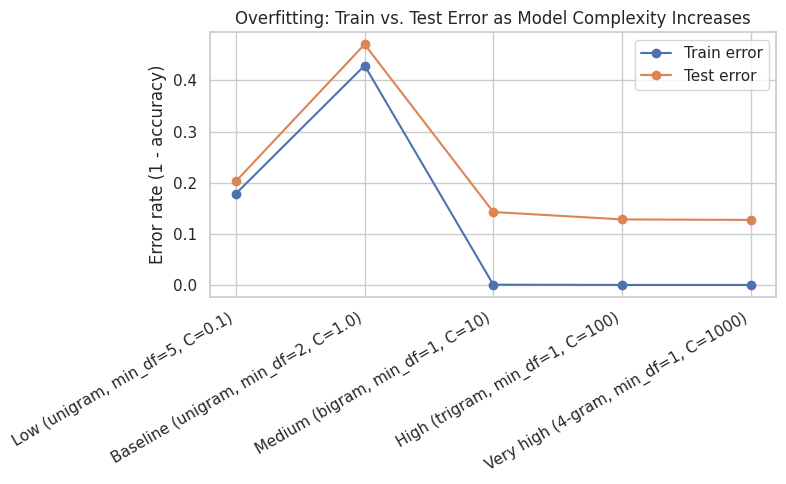


Gap between train and test error at each complexity level:
0    0.0241
1    0.0414
2    0.1420
3    0.1280
4    0.1270
dtype: float64


In [14]:
# visualization of the gaps between the training vs test model
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(sweep_df))
ax.plot(x, sweep_df["train_error"], marker="o", label="Train error")
ax.plot(x, sweep_df["test_error"], marker="o", label="Test error")
ax.set_xticks(list(x))
ax.set_xticklabels(sweep_df["setting"], rotation=30, ha="right")
ax.set_ylabel("Error rate (1 - accuracy)")
ax.set_title("Overfitting: Train vs. Test Error as Model Complexity Increases")
ax.legend()
plt.tight_layout()
plt.show()

# the growing gap is the overfitting
print("\nGap between train and test error at each complexity level:")
print((sweep_df["test_error"] - sweep_df["train_error"]).round(4))


In [15]:
# overfit the model by taking it to the most extreme point
overfit_model = build_lr_pipeline(ngram_range=(1, 4), min_df=1, max_df=1.0, C=1000.0)
overfit_model.fit(X_train, y_train)

# this model will be attacked in the next section
of_train_acc = accuracy_score(y_train, overfit_model.predict(X_train))
of_test_acc = accuracy_score(y_test, overfit_model.predict(X_test))
print(f"Overfit model — train accuracy: {of_train_acc:.4f}")
print(f"Overfit model — test accuracy:  {of_test_acc:.4f}")
print(f"Train/test gap: {of_train_acc - of_test_acc:.4f}  (baseline gap was {train_acc - test_acc:.4f})")

Overfit model — train accuracy: 0.9995
Overfit model — test accuracy:  0.8710
Train/test gap: 0.1285  (baseline gap was 0.0469)


## 7. **Failures**

Tests the model against a small set of hand written reviews that are designed to break it. There is sarcasm and backhanded compliments on purpose. Each example has a known correct answer and specific failure on how the model gets fooled.

In [16]:
# a list of deliberately tricky reviews designed to expose specific weaknesses in the model
adversarial_examples: List[Tuple[str, str, str]] = [
    # (text, true_label, failure_mechanism)
    ("Oh sure, this was just the BEST class ever, if you enjoy learning absolutely nothing "
     "and failing every exam.",
     "Awful", "Sarcasm: positive-sounding words used ironically"),

    ("great great great amazing amazing wonderful perfect, but I failed the class and he "
     "never showed up to office hours or answered a single email",
     "Awful", "Keyword stuffing: repeated positive tokens drown out the real (negative) content"),

    ("I would not say he is a bad professor.",
     "Neutral/mildly positive", "Negation: bag-of-words sees 'bad' and ignores the negation scope"),

    ("Not the worst professor I've had, honestly, and not the best either.",
     "Neutral", "Double negation + hedging that a token-counting model can't resolve"),

    ("For someone who clearly doesn't care about the students, he sure knows his material "
     "extremely well.",
     "Neutral/mixed", "Backhanded compliment: two competing sentiments in one sentence"),
]

def evaluate_adversarial(model, examples, model_name: str) -> pd.DataFrame:
    rows = []
    for text, true_label, mechanism in examples:
        pred = model.predict([text])[0]
        rows.append({
            "model": model_name, "true_label": true_label, "prediction": pred,
            "mechanism": mechanism, "text": text,
        })
    return pd.DataFrame(rows)

# dataframe that holds one row per adversarial example
adv_baseline = evaluate_adversarial(baseline_model, adversarial_examples, "baseline")
adv_overfit = evaluate_adversarial(overfit_model, adversarial_examples, "overfit")

adv_results = pd.concat([adv_baseline, adv_overfit], ignore_index=True)
pd.set_option("display.max_colwidth", 60)
adv_results[["model", "true_label", "prediction", "mechanism", "text"]]


,model,true_label,prediction,mechanism,text
0,baseline,Awful,Awful,Sarcasm: positive-sounding words used ironically,"Oh sure, this was just the BEST class ever, if you enjoy..."
1,baseline,Awful,Great,Keyword stuffing: repeated positive tokens drown out the...,"great great great amazing amazing wonderful perfect, but..."
2,baseline,Neutral/mildly positive,Awful,Negation: bag-of-words sees 'bad' and ignores the negati...,I would not say he is a bad professor.
3,baseline,Neutral,Awful,Double negation + hedging that a token-counting model ca...,"Not the worst professor I've had, honestly, and not the ..."
4,baseline,Neutral/mixed,Awful,Backhanded compliment: two competing sentiments in one s...,"For someone who clearly doesn't care about the students,..."
5,overfit,Awful,Great,Sarcasm: positive-sounding words used ironically,"Oh sure, this was just the BEST class ever, if you enjoy..."
6,overfit,Awful,Great,Keyword stuffing: repeated positive tokens drown out the...,"great great great amazing amazing wonderful perfect, but..."
7,overfit,Neutral/mildly positive,Awful,Negation: bag-of-words sees 'bad' and ignores the negati...,I would not say he is a bad professor.
8,overfit,Neutral,Awful,Double negation + hedging that a token-counting model ca...,"Not the worst professor I've had, honestly, and not the ..."
9,overfit,Neutral/mixed,Awful,Backhanded compliment: two competing sentiments in one s...,"For someone who clearly doesn't care about the students,..."


## 8. **Bias Analysis**

Checks if the model treats certain kinds of reviews differently for reasons that are not related to teaching. Specifically through the professors accent, language or appearance.It takes the descriptors and tests them, then sees which words held more weight.

In [17]:
# list of phrases to flag reviews that mention a professors accent/english
ACCENT_LANGUAGE_TERMS = [
    "accent", "hard to understand", "english is", "broken english",
    "thick accent", "hard to follow", "language barrier",
]

# list of phrases to flag reviews that mention gendered languge/appearance commentary
GENDERED_TERMS = [
    "bossy", "shrill", "bitchy", "she is a b", "her attitude",
    "too emotional", "unprofessional dress", "what she wore", "what she was wearing",
]

# sorts and searches the text for trigger phrases
def subgroup_mask(texts, terms) -> np.ndarray:
    pattern = "|".join(re.escape(t) for t in terms)
    return np.array([bool(re.search(pattern, str(t).lower())) for t in texts])

# runs the bias check
def subgroup_error_report(model, X, y_true, terms, group_name) -> None:
    mask = subgroup_mask(X, terms)
    n_hits = mask.sum()
    print(f"--- Subgroup: {group_name} ---")
    print(f"Matches in test set: {n_hits} / {len(X)}")
    if n_hits == 0:
        print("No matches in this test set — re-run on the full real dataset to get a "
              "meaningful subgroup size before drawing conclusions.\n")
        return
    y_true_sub, y_true_rest = y_true[mask], y_true[~mask]
    preds = model.predict(X)
    y_pred_sub, y_pred_rest = preds[mask], preds[~mask]
    acc_sub = accuracy_score(y_true_sub, y_pred_sub)
    acc_rest = accuracy_score(y_true_rest, y_pred_rest)
    awful_rate_sub = (y_pred_sub == "Awful").mean()
    awful_rate_rest = (y_pred_rest == "Awful").mean()
    print(f"Accuracy on subgroup:      {acc_sub:.4f}")
    print(f"Accuracy on rest of data:  {acc_rest:.4f}")
    print(f"Predicted 'Awful' rate, subgroup: {awful_rate_sub:.4f}")
    print(f"Predicted 'Awful' rate, rest:     {awful_rate_rest:.4f}")
    print()

for terms, name in [(ACCENT_LANGUAGE_TERMS, "accent / language-related complaints"),
                     (GENDERED_TERMS, "gendered language")]:
    subgroup_error_report(baseline_model, X_test, y_test, terms, name)

--- Subgroup: accent / language-related complaints ---
Matches in test set: 47 / 2000
Accuracy on subgroup:      0.5957
Accuracy on rest of data:  0.7563
Predicted 'Awful' rate, subgroup: 0.4681
Predicted 'Awful' rate, rest:     0.3574

--- Subgroup: gendered language ---
Matches in test set: 4 / 2000
Accuracy on subgroup:      0.7500
Accuracy on rest of data:  0.7525
Predicted 'Awful' rate, subgroup: 0.7500
Predicted 'Awful' rate, rest:     0.3592



In [18]:
# uses the logistic regression model to find the most heavy words to predict each class
def top_terms_per_class(pipeline: Pipeline, class_labels, top_n=15) -> Dict[str, List[str]]:
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    feature_names = np.array(vectorizer.get_feature_names_out())
    results = {}
    for i, cls in enumerate(clf.classes_):
        coefs = clf.coef_[i]
        top_idx = np.argsort(coefs)[-top_n:][::-1]
        results[cls] = list(feature_names[top_idx])
    return results

#  most predictive words per class
top_terms = top_terms_per_class(baseline_model, labels_order, top_n=15)
for cls, terms in top_terms.items():
    print(f"Top terms driving '{cls}' predictions:")
    print(", ".join(terms))
    print()

print("Manually scan the lists above for anything tied to accent/language, gender, appearance,")
print("or other protected/incidental characteristics rather than teaching quality itself —")
print("note any hits in the written report below.")

Top terms driving 'Awful' predictions:
not, even, worst, never, doesn, this, avoid, awful, no, extremely, does, impossible, rude, instructions, don

Top terms driving 'Great' predictions:
great, amazing, easy, best, helpful, interesting, cares, teacher, love, always, fun, caring, professor, enjoyed, helped

Top terms driving 'Neutral' predictions:
but, however, sometimes, pretty, lot, part, overall, were, anatomy, or, though, still, final, powerpoint, readings

Manually scan the lists above for anything tied to accent/language, gender, appearance,
or other protected/incidental characteristics rather than teaching quality itself —
note any hits in the written report below.


## 9. **References**


Diaz, M., Johnson, I., Lazar, A., Piper, A. M., & Gergle, D. (2018, April 21). Addressing Age-Related Bias in Sentiment Analysis. Proceedings of the 2018 CHI Conference on Human Factors in Computing Systems, 1-14. 10.1145/3173574.3173986

Gong, X., Ying, W., Zhong, S., & Gong, S. (2022, May 13). Text Sentiment Analysis Based on Transformer and Augmentation. Frontiers in Psychology, 13, 906061. 10.3389/fpsyg.2022.906061

Liu, M., Zhang, Z., Zhang, Y., Zhang, C., Li, Z., Li, Q., Duan, H., & Sun, D. (2023, March 1). Automatic Generation of Adversarial Readable Chinese Texts. IEEE Transactions on Dependable and Secure Computing, 20(2), 1756-1770. 10.1109/TDSC.2022.3164289


Savini, E., & Caragea, C. (2020, April 3). A Multi-Task Learning Approach to Sarcasm Detection (Student Abstract). Proceedings of the AAAI Conference on Artificial Intelligence, 34(10), 13907-13908. 10.1609/aaai.v34i10.7226

Zheng, X., Vastrad, S., He, J., & Ni, C. (2023, March 16). Contextualizing gender disparities in online teaching evaluations for professors. PLOS One, 18(3), e0282704. 10.1371/journal.pone.0282704

